In [2]:
import numpy as np
import pandas as pd
import os
import matplotlib.pyplot as plt
import torch
import torch.nn as nn
from PIL import Image
from torchvision import transforms
from torchvision.transforms import InterpolationMode
from torch.utils.data import DataLoader, Dataset, WeightedRandomSampler
from torchsummary import summary
from torch.optim.lr_scheduler import CosineAnnealingLR
from collections import Counter
import time
from sklearn.model_selection import train_test_split

In [40]:
# Setting for the the trianing 
tr_percentage = 0.30 # train on provided percetage of data from the entire dataset
if torch.cuda.is_available():
    device = 'cuda'
elif torch.backends.mps.is_available():
    device = 'mps'
else:
    device = 'cpu'

print(f"Using device: [{device}]")
print(f'Your are using {tr_percentage*100}% of your dataset')


Using device: [cuda]
Your are using 30.0% of your dataset


In [41]:
# Prepare the dataset directories 
# data_path = "food-classification/ifood-2019-fgvc6"
data_path = "/kaggle/input/datasets/hjhgkyo/food-dataset-ifood2019fgvc"
train_data = os.path.join(data_path, 'train_set/train_set')
test_data = os.path.join(data_path, 'val_set/val_set')

train_imgs = os.listdir(train_data) # get all training images files
test_imgs = os.listdir(test_data) # get all training images files
print(f'There are {len(train_imgs)} training and {len(test_imgs)} testing images')

There are 118475 training and 11994 testing images


In [42]:
# read the labels 
pdf = pd.read_csv(os.path.join(data_path, 'train_labels.csv'))
t_pdf = pd.read_csv(os.path.join(data_path, 'val_labels.csv'))
print(f'Ther are {pdf.isna().sum().sum()} images without labels')
pdf.count()

Ther are 0 images without labels


img_name    118475
label       118475
dtype: int64

In [43]:
# read the classes value
data_classes = pd.read_csv(os.path.join(data_path, 'class_list.txt'), sep=' ') 
data_classes.columns = ['id', 'name']
NUM_CLASSES = len(data_classes)+1
# plot the all class distributions 
all_classes = pdf['label']

# Stratified sampling to get xx% from each class
# trainable_pdf = pdf.groupby('label', group_keys=False).sample(frac=tr_percentage, random_state=42)
trainable_pdf = (
    pdf.groupby('label', group_keys=False)
    .apply(lambda x: x.sample(
        max(2, int(len(x) * tr_percentage)),
        random_state=42
    ).assign(label=x.name), include_groups=False)
)

# test_pdf = t_pdf.groupby('label', group_keys=False).sample(frac=tr_percentage, random_state=42)
test_pdf = (
    t_pdf.groupby('label', group_keys=False)
    .apply(lambda x: x.sample(
        max(2, int(len(x) * tr_percentage)),
        random_state=42
    ).assign(label=x.name), include_groups=False)
)

print(f'There are {NUM_CLASSES} classes')
print(f'There are {len(trainable_pdf)} images for training and validation')


There are 251 classes
There are 35424 images for training and validation


In [7]:
# plot the class distribution
def plot_class_distributions(num_labels, percentage = 100):
    """
    This method will plot the labels distribution passed in the histogram format
    """
    counts = Counter(num_labels)
    min_class = min(counts, key=counts.get)
    max_class = max(counts, key=counts.get)

    print(f"""
        Min class: {min_class}  ––> {counts[min_class]} images
        Max class: {max_class} ––> {counts[max_class]} images 
    """)

    plt.figure(figsize=(12, 5))
    plt.hist(num_labels, bins=NUM_CLASSES, color='skyblue', edgecolor='black', alpha=0.8)
    plt.title(f"""
        Distribution of {percentage}% Labels
        Min class: {min_class}  ––> {counts[min_class]} images
        Max class: {max_class} ––> {counts[max_class]} images 
    """)
    plt.xlabel('Label Value')
    plt.ylabel('Frequency')
    plt.grid(axis='y', linestyle='--', alpha=0.7)
    plt.tight_layout()
    plt.show()


        Min class: 162  ––> 34 images
        Max class: 218 ––> 656 images 
    


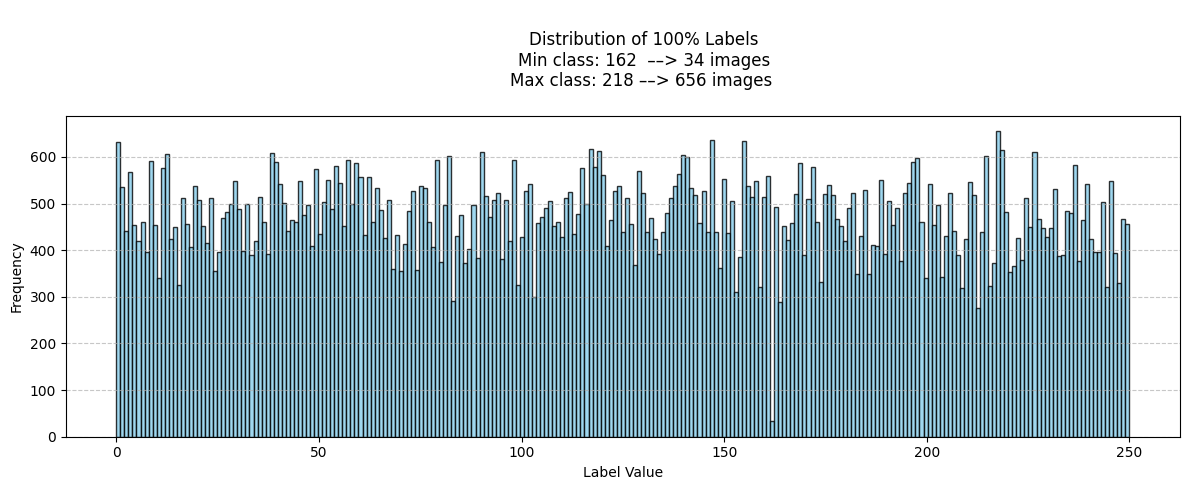

In [8]:
# plot all class distributions 
plot_class_distributions(all_classes)


        Min class: 162  ––> 10 images
        Max class: 218 ––> 196 images 
    


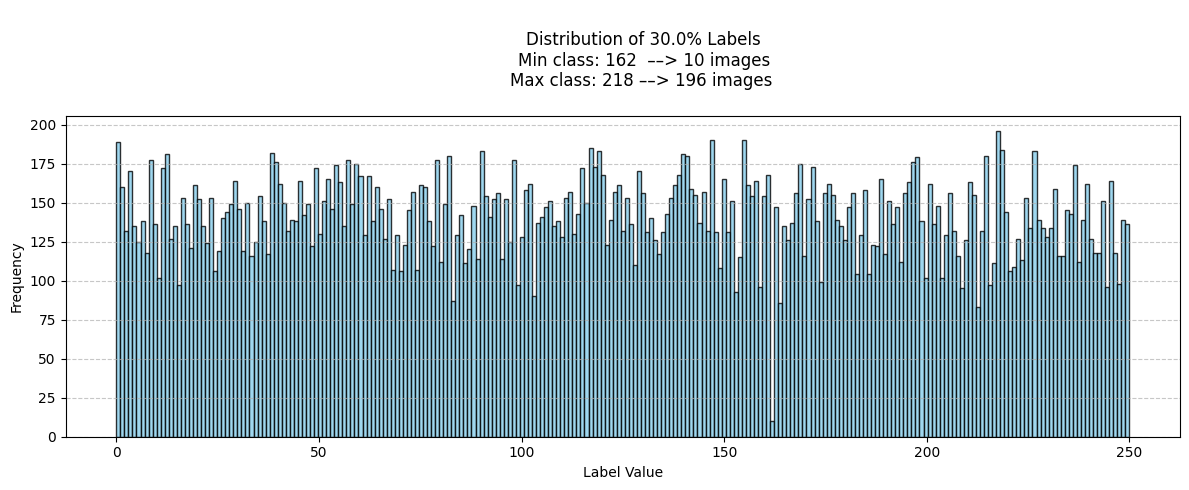

In [44]:
# plot the sampled classes distribution
plot_class_distributions(trainable_pdf['label'], tr_percentage*100)

In [10]:
glb_mean = [0.485, 0.456, 0.406]
glb_std = [0.229, 0.224, 0.225]

In [45]:
# load the ground throught dataset and evaluate against the SSL model
class Myclass(Dataset):
    def __init__(self, df, dir='train_set/train_set', transform=None):
        super().__init__()
        self.df = df 
        self.dir = dir # images directory
        self.transform = transform 
    def __len__(self):
        return len(self.df)
    def __getitem__(self, idx):
        file = self.df.iloc[idx].values
        img_name = file[0]
        label = file[1]
        img = Image.open(os.path.join(data_path, self.dir, img_name))
        if self.transform:
            img = self.transform(img)
        return img, label

In [46]:
# split the train dataset in training (75%), validation (25%)
training_df, validation_df = train_test_split(
    trainable_pdf,
    test_size=0.25,
    stratify=trainable_pdf['label'],
    random_state=42
)
print(f'{len(training_df)} images for training \n{len(validation_df)} images for validation \n{len(test_pdf)} images for testinng.')

26568 images for training 
8856 images for validation 
3485 images for testinng.



        Min class: 162  ––> 7 images
        Max class: 218 ––> 147 images 
    


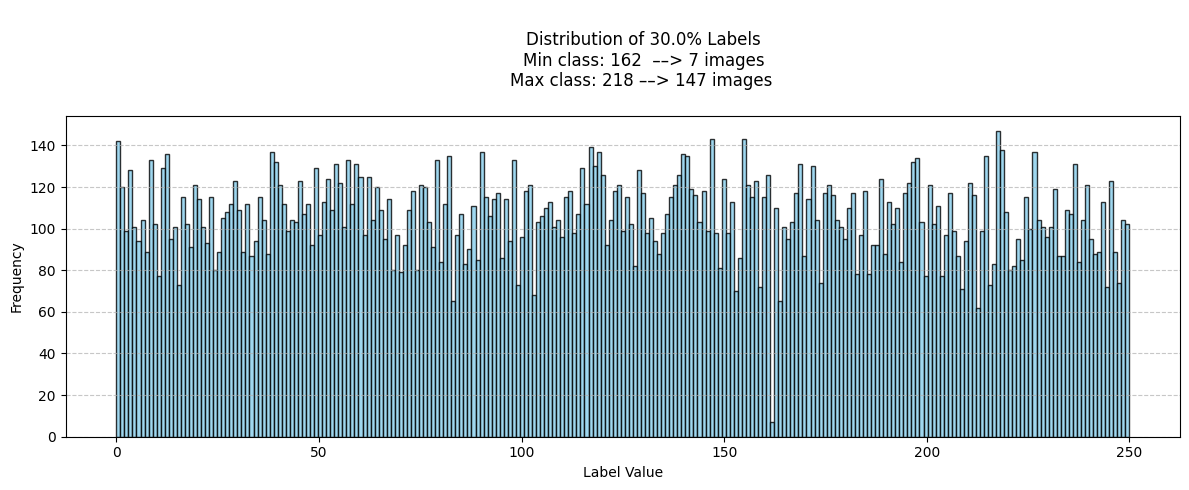


        Min class: 162  ––> 3 images
        Max class: 218 ––> 49 images 
    


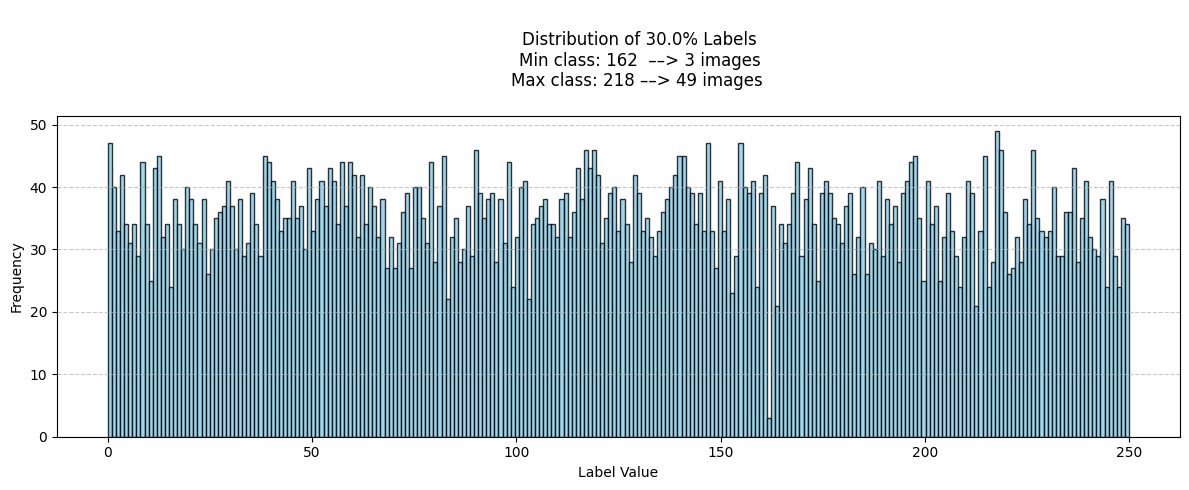


        Min class: 116  ––> 2 images
        Max class: 34 ––> 20 images 
    


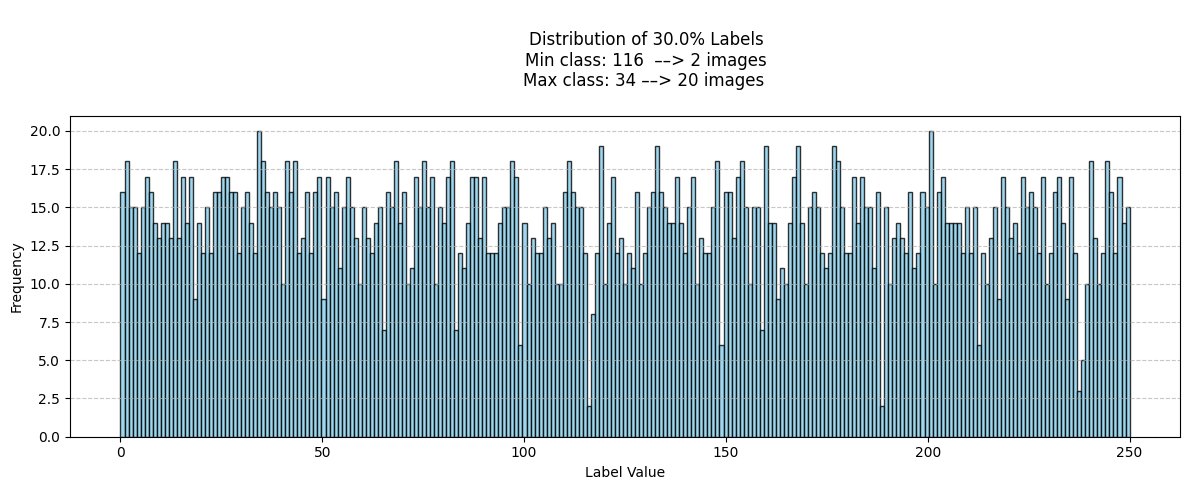

In [47]:
# Training dataset distribution
plot_class_distributions(training_df['label'], tr_percentage*100)

# Validation dataset distribution
plot_class_distributions(validation_df['label'], tr_percentage*100)

# Testing dataset distribution
plot_class_distributions(test_pdf['label'], tr_percentage*100)


In [49]:
SIZE = 160
train_transform = transforms.Compose([
    transforms.Resize(size=(SIZE+20, SIZE+20), interpolation=InterpolationMode.BICUBIC),
    
    transforms.RandomCrop(SIZE, padding=6),
    transforms.RandomHorizontalFlip(p=0.5), 
    transforms.RandomRotation(degrees=15),

    transforms.ColorJitter(
        brightness=0.3,
        contrast=0.3,
        saturation=0.3,
        hue=0.03
    ),
    transforms.ToTensor(),
    transforms.Normalize(mean=glb_mean, std=glb_std),
])
val_transform = transforms.Compose([  
    transforms.Resize(size=(SIZE, SIZE), interpolation=InterpolationMode.BICUBIC),
    transforms.ToTensor(),
    transforms.Normalize(mean=glb_mean, std=glb_std),
])

In [50]:
# Get the training, validation, and testing datas
train_data = Myclass(training_df, 'train_set/train_set', train_transform)
val_data = Myclass(validation_df, 'train_set/train_set', val_transform)
test_data = Myclass(test_pdf, 'val_set/val_set', val_transform)
len(train_data), len(val_data), len(test_data)

(26568, 8856, 3485)

In [51]:
# Handle class imbalance 

counts = Counter(training_df['label']) # calculate class count

weights = []
for c in range(251):
    cnt = max(counts[c], 1) # to prevent division by zero if 0 class 
    weights.append(1.0 / np.sqrt(cnt)) # SQRT applied to make it more softner instead of raw count

weights = torch.tensor(weights, dtype=torch.float32)
weights = weights / weights.sum() * len(weights) # normalize the class weight
weight=weights.to(device)


# WeightedRandomSampler is useful when:

# Map these normalized weights to every row pdf
sample_weights = [weights[label].item() for label in training_df['label']]

# Create sampler
sampler = WeightedRandomSampler(
    weights=sample_weights,
    num_samples=len(sample_weights),
    replacement=True
)
len(counts), len(weights)

(251, 251)

In [53]:
# Add data loader 
BATCH_SIZE = 64
PIN_MEMORY = True if device == 'cuda' or device == 'mps' else False
NUM_WORKERS = 0
train_loader = DataLoader(train_data,
                          batch_size=BATCH_SIZE,
                          shuffle=False, 
                          sampler=sampler,
                          drop_last=True, 
                          pin_memory=PIN_MEMORY,
                          num_workers=NUM_WORKERS)
val_loader = DataLoader(val_data, batch_size=BATCH_SIZE, shuffle=False, drop_last=False, pin_memory=PIN_MEMORY, num_workers=NUM_WORKERS)
test_loader = DataLoader(test_data, batch_size=BATCH_SIZE, shuffle=False, drop_last=False, pin_memory=PIN_MEMORY, num_workers=NUM_WORKERS)
print(f"There are \n {len(train_loader)} training batches \n {len(val_loader)} validation batches \n {len(test_loader)} testing batches")

There are 
 415 training batches 
 139 validation batches 
 55 testing batches


In [54]:
class ResidualBlock(nn.Module):
    def __init__(self, in_ch, out_ch, stride=1):
        super().__init__() 
        
        self.doubleConve = nn.Sequential(
            nn.Conv2d(in_ch, out_ch, 3, stride=stride, padding=1, bias=False), # No bias also save GPU
            nn.BatchNorm2d(out_ch),
            nn.ReLU(inplace=True), # Faster with GPU
            nn.Conv2d(out_ch, out_ch, 3, stride=1, padding=1, bias=False), 
            nn.BatchNorm2d(out_ch),
        )
        
        self.skip = nn.Identity()
        if in_ch != out_ch or stride !=1:
            self.skip = nn.Sequential(
                nn.Conv2d(in_ch, out_ch, 1, stride=stride, padding=0, bias=False), 
                nn.BatchNorm2d(out_ch),
            ) 
        self.relu = nn.ReLU(inplace=True)
    def forward(self, x):
        residual = self.skip(x)
        out = self.doubleConve(x)
        out = out + residual 
        out = self.relu(out) # added residual
        return out


In [19]:
class ResNet(nn.Module):
    def __init__(self):
        super().__init__()
        # input layer
        self.prep = nn.Sequential(
            nn.Conv2d(3, 32, kernel_size=3, stride=2, padding=1, bias=False),
            nn.BatchNorm2d(32),
            nn.ReLU(inplace=True)
        )
        # Encoder
        self.block1 = nn.Sequential(ResidualBlock(32, 32, stride=1), ResidualBlock(32, 32, stride=1))      
        self.block2 = nn.Sequential(ResidualBlock(32, 64, stride=2), ResidualBlock(64, 64, stride=1))      
        self.block3 = nn.Sequential(ResidualBlock(64, 128, stride=2), ResidualBlock(128, 128, stride=1))      
        self.block4 = nn.Sequential(ResidualBlock(128, 256, stride=2), ResidualBlock(256, 256, stride=1))      
        self.block5 = nn.Sequential(ResidualBlock(256, 512, stride=2))      

    def forward(self, x): 
        x = self.prep(x)
        x = self.block1(x)
        x = self.block2(x)
        x = self.block3(x)
        x = self.block4(x)
        x = self.block5(x)
        return x

resnet = ResNet().to(device)
# summary(resnet, input_size=(3, 64, 64))

In [20]:
class RotationNet(nn.Module):
    def __init__(self):
        super().__init__()
        self.encoder = ResNet()
        self.head = nn.Sequential(
            nn.AdaptiveAvgPool2d((1,1)),
            nn.Flatten(),
            nn.Linear(512, 4)
        )
    def forward(self, x):
        x = self.encoder(x)
        x = self.head(x)
        return x
rotationNet = RotationNet().to(device)
base_model = rotationNet
# prevents the GPU from wasting time reading and writing intermediate steps to memory.
rotationNet = torch.compile(rotationNet) # Fuses the graph for massive speedups

In [55]:
loaded_model = RotationNet().to(device)
loaded_model.load_state_dict(
    torch.load('/kaggle/input/models/nawrozmohammadi/features/pytorch/default/1/rotaion_0_last_model.pth',
               weights_only=True, map_location=torch.device(device)))
loaded_model.eval()

RotationNet(
  (encoder): ResNet(
    (prep): Sequential(
      (0): Conv2d(3, 32, kernel_size=(3, 3), stride=(2, 2), padding=(1, 1), bias=False)
      (1): BatchNorm2d(32, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (2): ReLU(inplace=True)
    )
    (block1): Sequential(
      (0): ResidualBlock(
        (doubleConve): Sequential(
          (0): Conv2d(32, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
          (1): BatchNorm2d(32, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
          (2): ReLU(inplace=True)
          (3): Conv2d(32, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
          (4): BatchNorm2d(32, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
        )
        (skip): Identity()
        (relu): ReLU(inplace=True)
      )
      (1): ResidualBlock(
        (doubleConve): Sequential(
          (0): Conv2d(32, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=Fal

In [22]:
# visualize feature maps or deeper layer activations to see how model is learning

layers = {
    "Block 1 (Low-level edges)": loaded_model.encoder.block1,
    "Block 2 (Textures)": loaded_model.encoder.block2,
    "Block 3 (Shapes)": loaded_model.encoder.block3,
    "Block 4 (High-level patterns)": loaded_model.encoder.block4,
}

In [23]:
activations = {}
handles = []
# Create hooks
def get_hook(name):
    def hook(module, input, output):
        activations[name] = output.detach()
    return hook

for name, layer in layers.items():
    handles.append(layer.register_forward_hook(get_hook(name))) # register and add to handles

/tmp/ipykernel_58/3887675640.py:3: DeprecationWarning: __array__ implementation doesn't accept a copy keyword, so passing copy=False failed. __array__ must implement 'dtype' and 'copy' keyword arguments. To learn more, see the migration guide https://numpy.org/devdocs/numpy_2_0_migration_guide.html#adapting-to-changes-in-the-copy-keyword
  org_img = np.array(org_img.cpu().permute(1,2,0))


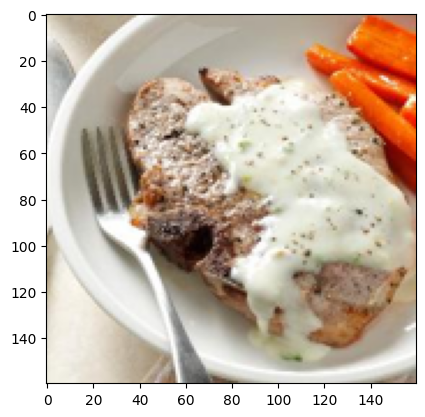

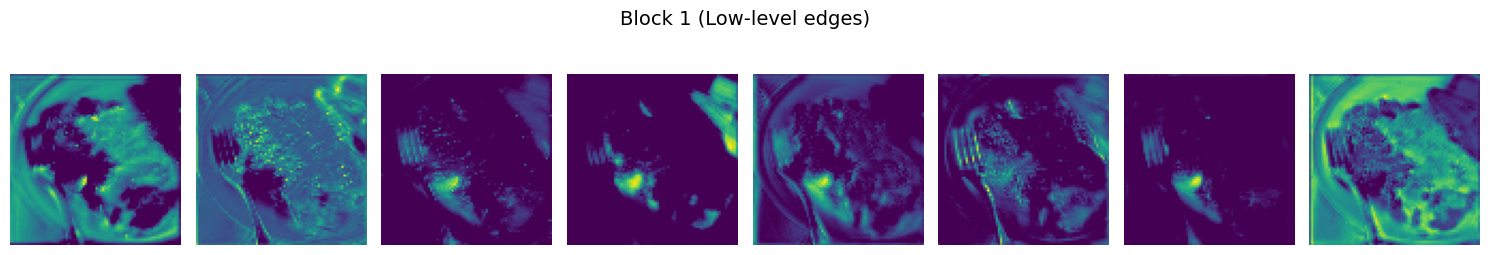

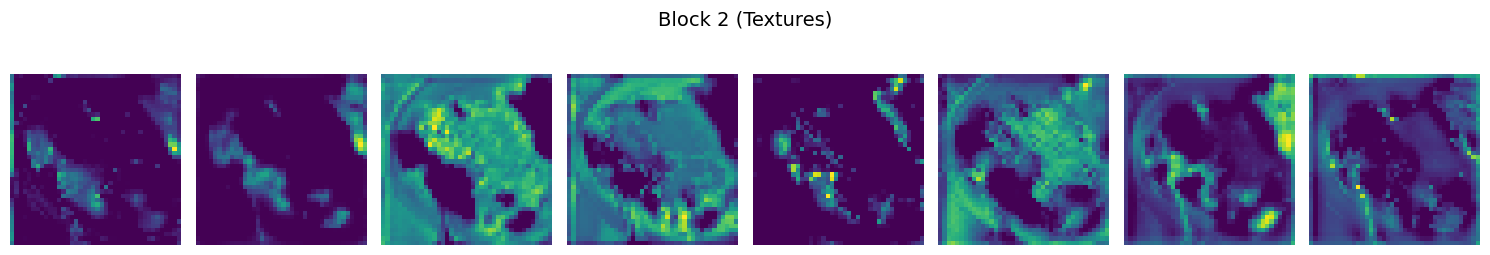

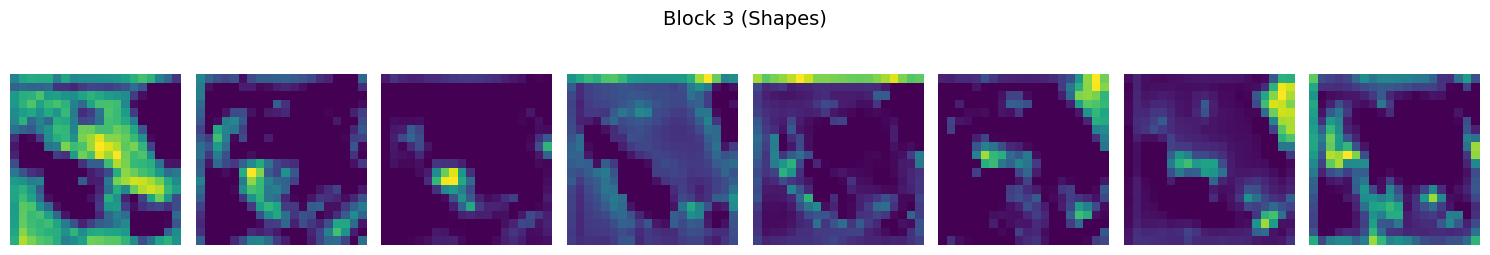

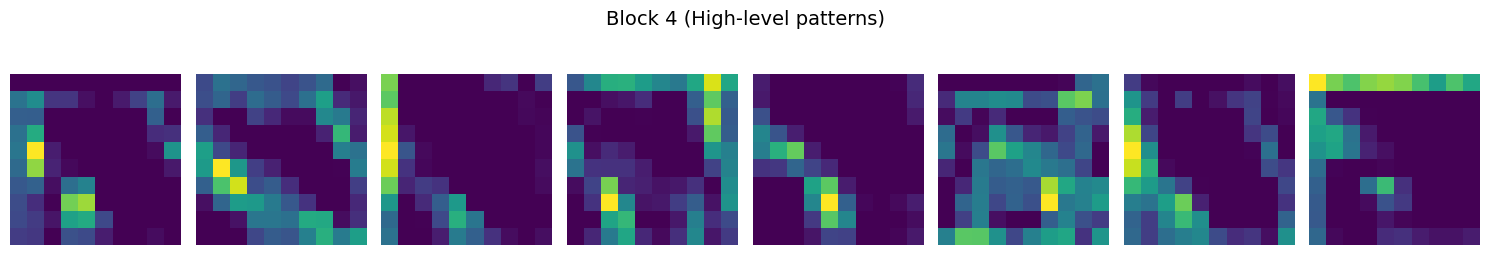

In [27]:
 img, label = test_data.__getitem__(np.random.randint(len(test_data)))
org_img = img
org_img = np.array(org_img.cpu().permute(1,2,0))
#  denormalize
org_img = glb_std * org_img + glb_mean
org_img = np.clip(org_img, 0, 1)

plt.imshow(org_img)
plt.show()

img = img.unsqueeze(0).float().to(device)

loaded_model.eval()

with torch.no_grad():
    _ = loaded_model(img)


def plot_layer_features(feat_maps, title, n=8):
    fmap = feat_maps[0]  # [C, H, W]

    plt.figure(figsize=(15, 5))
    plt.suptitle(title, fontsize=14)

    for i in range(n):
        plt.subplot(2, 8, i + 1)
        plt.imshow(fmap[i].cpu())
        plt.axis("off")

    plt.tight_layout()
    plt.show()
for name in layers.keys():
    plot_layer_features(activations[name], name, n=8)

In [28]:
loaded_encoder = loaded_model.encoder # keep only encoder

In [56]:
# Freeze the encoder 
for p in loaded_encoder.block1.parameters(): p.requires_grad = False
for p in loaded_encoder.block2.parameters(): p.requires_grad = False
# for p in loaded_encoder.block3.parameters(): p.requires_grad = False

In [57]:
# Unfreeze the 3th block
for p in loaded_encoder.block3.parameters():
    p.requires_grad = True
    
# Unfreeze the 4th block
for p in loaded_encoder.block4.parameters():
    p.requires_grad = True
    
# Unfreeze the last block
for p in loaded_encoder.block5.parameters():
    p.requires_grad = True

In [59]:
class FoodClassifier(nn.Module):
    def __init__(self, encoder):
        super().__init__()

        self.encoder = loaded_encoder

        self.head = nn.Sequential(
            nn.AdaptiveAvgPool2d((1,1)),
            nn.Flatten(),
        
            nn.Linear(512, 1024),
            nn.BatchNorm1d(1024),
            nn.ReLU(),
            nn.Dropout(0.5),
        
            nn.Linear(1024, 512),
            nn.BatchNorm1d(512),
            nn.ReLU(),
            nn.Dropout(0.5),
        
            nn.Linear(512, 251)
        )

    def forward(self, x):
        x = self.encoder(x)
        x = self.head(x)
        return x
food_cls_base = FoodClassifier(loaded_encoder).to(device)
food_cls = food_cls_base
food_cls = torch.compile(food_cls)

In [60]:
trainable = sum(
    p.numel() for p in food_cls.parameters()
    if p.requires_grad
)

print(trainable)

7481243


In [34]:
print(sum(p.requires_grad for p in loaded_encoder.parameters()))

42


In [61]:
# Setup the model compiler
EPOCHS = 50
# optimizer = torch.optim.AdamW(food_cls.parameters(), lr=3e-4, weight_decay=1e-4) 
optimizer = torch.optim.AdamW([
    {"params": food_cls.head.parameters(), "lr": 3e-4},
    {"params": food_cls.encoder.block3.parameters(), "lr": 1e-6}, 
    {"params": food_cls.encoder.block4.parameters(), "lr": 5e-6}, 
    {"params": food_cls.encoder.block5.parameters(), "lr": 1e-6}
], weight_decay=5e-4)

# loss method 
loss_fun = nn.CrossEntropyLoss()

# per-epoch stepping
scheduler = CosineAnnealingLR(optimizer, T_max=EPOCHS, eta_min=1e-6)

In [63]:
# Create a training method for non-labeled data
scaler = torch.amp.GradScaler('cuda') # also speed up training 
def train_model(model, dataloader, loss_fun, optimizer):
  training_loss, total, correct = 0, 0, 0 
  model.train()
  # model.encoder.eval() # make sure that encoder is not changing  
    
  for batch, (X, y), in enumerate(dataloader):
    X, y = X.to(device), y.to(device)
    if y.ndim == 2:
        y = y.squeeze(1)
    y = y.long()
    optimizer.zero_grad(set_to_none=True) # reset the gradient

    # Enable aMP for the forward pass
    with torch.autocast(device_type="cuda", dtype=torch.float16):
        y_pred = model(X) # (B, C, H, W)
        loss = loss_fun(y_pred, y) # calculate the loss

    # scale loss and backpropagate
    scaler.scale(loss).backward() # comput the gradient
    scaler.step(optimizer) # update the weight
    scaler.update()
      
    training_loss += loss.item()
    # Calculate the training accuracy
    preds = torch.argmax(y_pred, dim=1)
    correct += (preds == y).sum().item()
    total += y.size(0) 
    
    if (batch+1 == len(dataloader)):
      print(f'Batch {batch+1}/{len(dataloader)} | Loss: {loss.item():.4f}')
  training_acc = correct / total 
  return training_loss/len(dataloader), training_acc,

In [64]:
# Create a validation method
def validate_model(model, dataloader, loss_fun, epoch):
  model.eval()
  val_loss, correct, total = 0, 0, 0
  with torch.no_grad():
    for batch, (X, y) in enumerate(dataloader):
      X, y = X.to(device), y.to(device)
      if y.ndim == 2:
        y = y.squeeze(1)
      y = y.long()

      # Enable AMP for the forward pass
      with torch.autocast(device_type="cuda", dtype=torch.float16):
          y_pred = model(X)
          loss = loss_fun(y_pred, y)
      val_loss += loss.item() 
      preds = torch.argmax(y_pred, dim=1)
      correct += (preds == y).sum().item()
      total += y.size(0)

    val_acc = correct/total
  return val_loss/len(dataloader), val_acc

In [65]:
# Check how many trainable parameters we have there shouldn't be encoder
for name, p in food_cls.named_parameters():
    if p.requires_grad:
        print(name)

_orig_mod.encoder.prep.0.weight
_orig_mod.encoder.prep.1.weight
_orig_mod.encoder.prep.1.bias
_orig_mod.encoder.block3.0.doubleConve.0.weight
_orig_mod.encoder.block3.0.doubleConve.1.weight
_orig_mod.encoder.block3.0.doubleConve.1.bias
_orig_mod.encoder.block3.0.doubleConve.3.weight
_orig_mod.encoder.block3.0.doubleConve.4.weight
_orig_mod.encoder.block3.0.doubleConve.4.bias
_orig_mod.encoder.block3.0.skip.0.weight
_orig_mod.encoder.block3.0.skip.1.weight
_orig_mod.encoder.block3.0.skip.1.bias
_orig_mod.encoder.block3.1.doubleConve.0.weight
_orig_mod.encoder.block3.1.doubleConve.1.weight
_orig_mod.encoder.block3.1.doubleConve.1.bias
_orig_mod.encoder.block3.1.doubleConve.3.weight
_orig_mod.encoder.block3.1.doubleConve.4.weight
_orig_mod.encoder.block3.1.doubleConve.4.bias
_orig_mod.encoder.block4.0.doubleConve.0.weight
_orig_mod.encoder.block4.0.doubleConve.1.weight
_orig_mod.encoder.block4.0.doubleConve.1.bias
_orig_mod.encoder.block4.0.doubleConve.3.weight
_orig_mod.encoder.block4.0.

In [66]:
output_path = "/kaggle/working"
history = {
    "train_loss": [],
    "train_acc": [],
    "val_loss": [],
    "val_acc": [], 
    "head_lr": [], 
    "encoder_lr": [], 
}
best_val_loss = float('inf')

patience, epochs_no_improve = 10, 0
best_val_acc = 0
start_train_time = time.time()
for i in range(EPOCHS):
    print(f'Epoch {i+1}:')
    tr_loss, tr_acc = train_model(food_cls, train_loader, loss_fun, optimizer)
    history['train_acc'].append(tr_acc)
    history['train_loss'].append(tr_loss) 
    scheduler.step()

    val_loss, val_acc = validate_model(food_cls, val_loader, loss_fun, i+1)
    history['val_acc'].append(val_acc)
    history['val_loss'].append(val_loss) 
    # history['head_lr'].append(optimizer.param_groups[0]['lr'])
    # history['encoder_lr'].append(optimizer.param_groups[1]['lr'])
    
    head_lr = optimizer.param_groups[0]['lr']
    encoder_lr = optimizer.param_groups[1]['lr']
    history['head_lr'].append(head_lr)
    history['encoder_lr'].append(encoder_lr)
    
    print(f"""
    tr loss [{tr_loss:.4f}] | val loss [{val_loss:.4f}]
    tr acc [{tr_acc:.4f}] | val acc [{val_acc:.4f}] |  [head lr [{head_lr:.6f}] | encoder lr [{encoder_lr:.6f}]
    """) 

    # Save only weights of the best model 
    if val_acc > best_val_acc:
        best_val_acc = val_acc
        epochs_no_improve = 0
        torch.save(food_cls_base.state_dict(), f'{output_path}/food_cls_0_best_model_weights.pth')
        print("Best model saved!")
    else:
        epochs_no_improve += 1
        if epochs_no_improve >= patience:
            print(f"Early stopping at epoch {i+1}")
            break
torch.save(food_cls_base.state_dict(), f'{output_path}/food_cls_0_last_model.pth')
print(f'Last model saved correctly')
end_train_time = time.time()
print(f'End training after {(end_train_time - start_train_time)/60:.4f} minutes')

Epoch 1:
Batch 415/415 | Loss: 5.4979

    tr loss [5.5199] | val loss [5.3371]
    tr acc [0.0093] | val acc [0.0189] |  [head lr [0.000300] | encoder lr [0.000001]
    
Best model saved!
Epoch 2:
Batch 415/415 | Loss: 5.4753

    tr loss [5.4052] | val loss [5.2874]
    tr acc [0.0127] | val acc [0.0200] |  [head lr [0.000299] | encoder lr [0.000001]
    
Best model saved!
Epoch 3:
Batch 415/415 | Loss: 5.2401

    tr loss [5.3673] | val loss [5.2694]
    tr acc [0.0155] | val acc [0.0230] |  [head lr [0.000297] | encoder lr [0.000001]
    
Best model saved!
Epoch 4:
Batch 415/415 | Loss: 5.3574

    tr loss [5.3169] | val loss [5.2326]
    tr acc [0.0189] | val acc [0.0248] |  [head lr [0.000295] | encoder lr [0.000001]
    
Best model saved!
Epoch 5:
Batch 415/415 | Loss: 5.2869

    tr loss [5.2920] | val loss [5.2209]
    tr acc [0.0204] | val acc [0.0246] |  [head lr [0.000293] | encoder lr [0.000001]
    
Epoch 6:
Batch 415/415 | Loss: 5.2426

    tr loss [5.2637] | val loss [5

<Axes: >

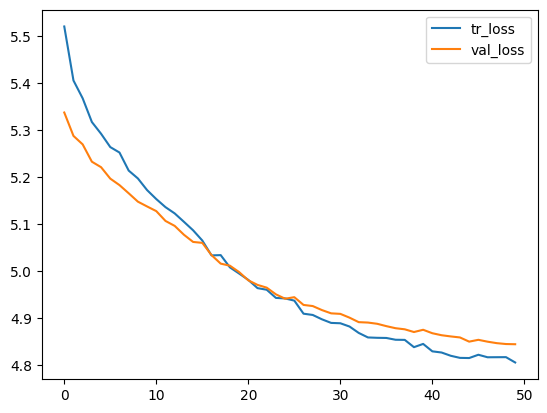

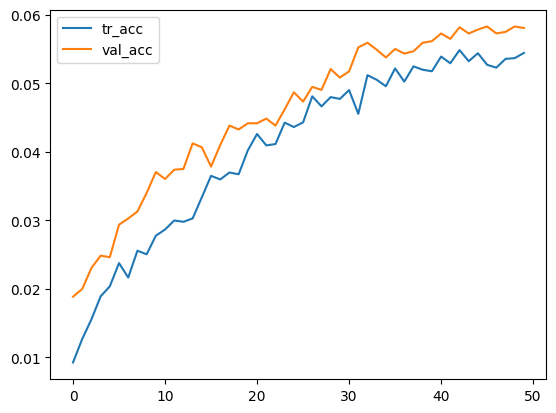

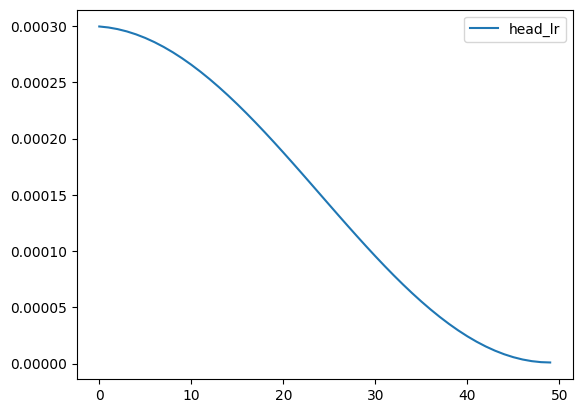

In [68]:
# Plot the learning curve 
pd.DataFrame({'tr_loss': history['train_loss'], 'val_loss': history['val_loss']}).plot()
pd.DataFrame({'tr_acc': history['train_acc'], 'val_acc': history['val_acc']}).plot()
pd.DataFrame({'head_lr': history['head_lr']}).plot()

In [69]:
loaded_ssl_model = FoodClassifier(loaded_encoder).to(device)
loaded_ssl_model.load_state_dict(
    torch.load('/kaggle/working/food_cls_0_last_model.pth',
               weights_only=True, map_location=torch.device(device)))
loaded_ssl_model.eval() 

FoodClassifier(
  (encoder): ResNet(
    (prep): Sequential(
      (0): Conv2d(3, 32, kernel_size=(3, 3), stride=(2, 2), padding=(1, 1), bias=False)
      (1): BatchNorm2d(32, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (2): ReLU(inplace=True)
    )
    (block1): Sequential(
      (0): ResidualBlock(
        (doubleConve): Sequential(
          (0): Conv2d(32, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
          (1): BatchNorm2d(32, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
          (2): ReLU(inplace=True)
          (3): Conv2d(32, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
          (4): BatchNorm2d(32, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
        )
        (skip): Identity()
        (relu): ReLU(inplace=True)
      )
      (1): ResidualBlock(
        (doubleConve): Sequential(
          (0): Conv2d(32, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=

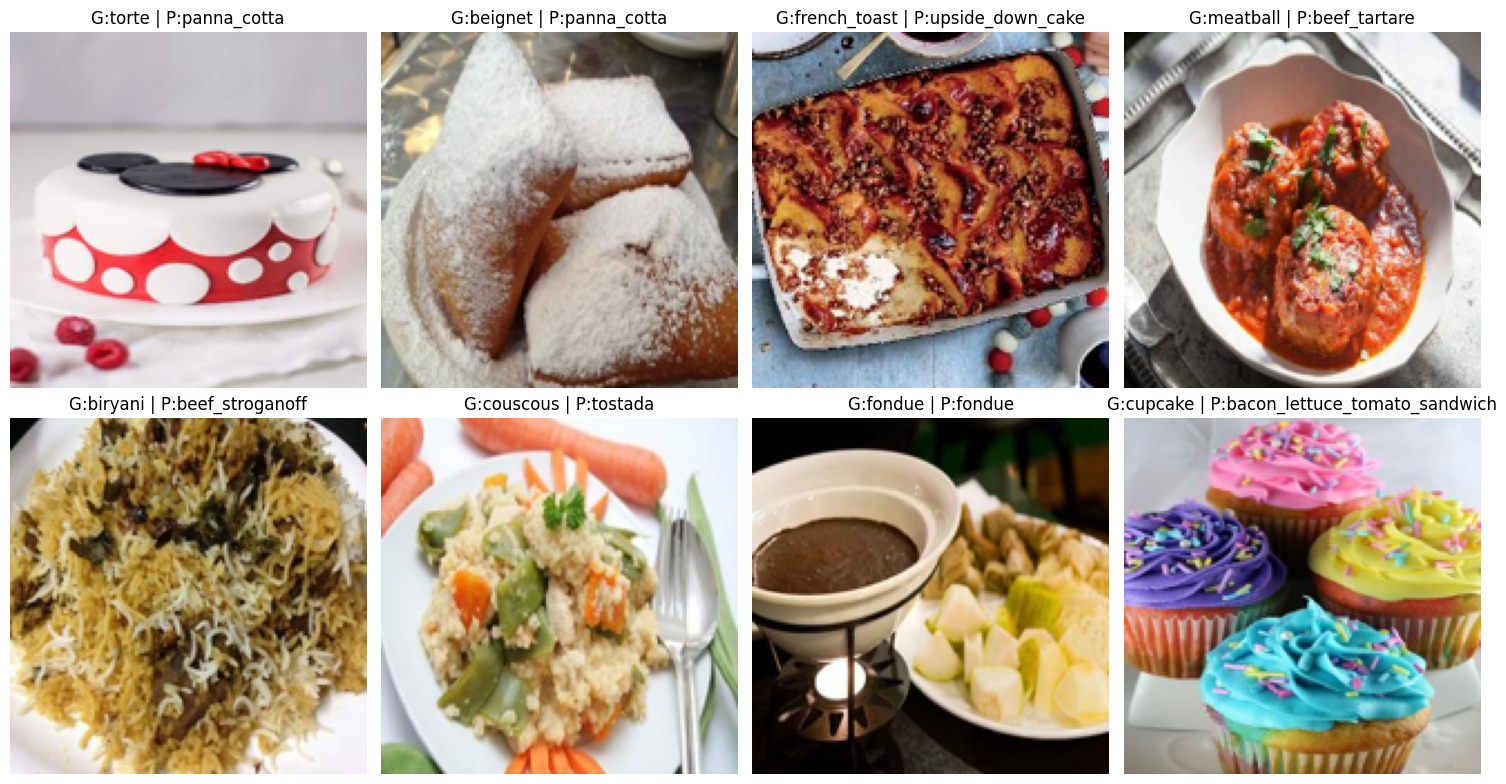

In [70]:
plt.figure(figsize=(15, 8))
for i in range(8):    
    img, label = test_data.__getitem__(np.random.randint(len(test_data)))
    
    img = img.unsqueeze(0).float().to(device)
    
    loaded_ssl_model.eval()
    
    loaded_ssl_model.eval()
    
    with torch.no_grad():
        y_pred = loaded_ssl_model(img)
    pred_label = y_pred.argmax(dim=1).item()
    img_np = img.squeeze(0).cpu().permute(1, 2, 0).numpy()
    #  denormalize
    img_np = glb_std * img_np + glb_mean
    img_np = np.clip(img_np, 0, 1)
    
    title_text = data_classes.iloc[label-1:label]['name'].values[0]
    pred_text = data_classes.iloc[pred_label-1:pred_label]['name'].values[0]
    
    plt.subplot(2, 4, i + 1)
    plt.imshow(img_np)
    plt.title(f'G:{title_text} | P:{pred_text}')
    plt.axis('off')

plt.tight_layout()
plt.show()


In [71]:

from sklearn.metrics import precision_score, recall_score, f1_score
all_preds = []
all_labels = []

# Evaluate mode on validation data
with torch.no_grad():
    for X, y in val_loader:
        X = X.to(device)

        if y.ndim == 2:
            y = y.squeeze(1)

        outputs = loaded_ssl_model(X)
        preds = torch.argmax(outputs, dim=1)

        all_preds.extend(preds.cpu().numpy())
        all_labels.extend(y.numpy())

precision = precision_score(
    all_labels,
    all_preds,
    average='macro',
    zero_division=0
)

recall = recall_score(
    all_labels,
    all_preds,
    average='macro',
    zero_division=0
)

f1 = f1_score(
    all_labels,
    all_preds,
    average='macro',
    zero_division=0
)

print(f"Precision: {precision:.4f}")
print(f"Recall:    {recall:.4f}")
print(f"F1 Score:  {f1:.4f}")

Precision: 0.0383
Recall:    0.0565
F1 Score:  0.0387


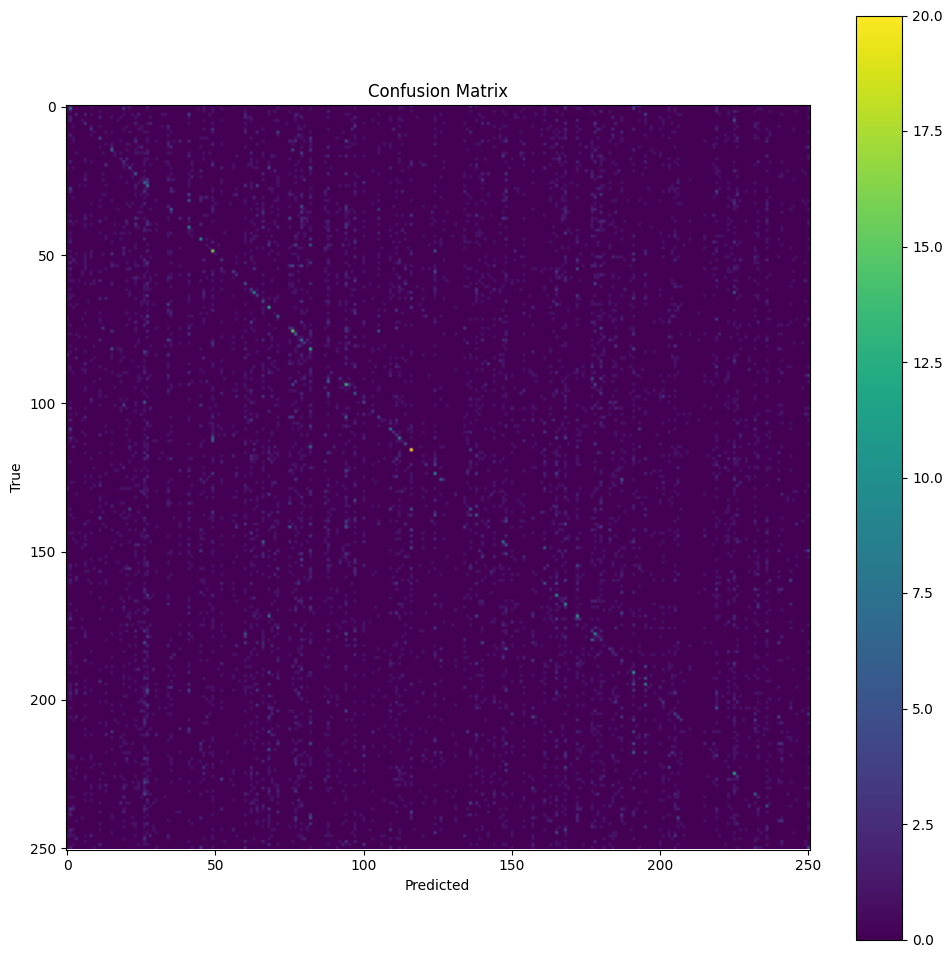

In [75]:
from sklearn.metrics import confusion_matrix

cm = confusion_matrix(all_labels, all_preds)
plt.figure(figsize=(12, 12))
plt.imshow(cm)
plt.colorbar()
plt.xlabel("Predicted")
plt.ylabel("True")
plt.title("Confusion Matrix")
plt.show()

In [72]:

t_all_preds = []
t_all_labels = []

# Evaluate mode on test data
with torch.no_grad():
    for X, y in test_loader:
        X = X.to(device)

        if y.ndim == 2:
            y = y.squeeze(1)

        outputs = loaded_ssl_model(X)
        preds = torch.argmax(outputs, dim=1)

        t_all_preds.extend(preds.cpu().numpy())
        t_all_labels.extend(y.numpy())

precision = precision_score(
    t_all_labels,
    t_all_preds,
    average='macro',
    zero_division=0
)

recall = recall_score(
    t_all_labels,
    t_all_preds,
    average='macro',
    zero_division=0
)

f1 = f1_score(
    t_all_labels,
    t_all_preds,
    average='macro',
    zero_division=0
)

print(f"Precision: {precision:.4f}")
print(f"Recall:    {recall:.4f}")
print(f"F1 Score:  {f1:.4f}")

Precision: 0.0462
Recall:    0.0607
F1 Score:  0.0446


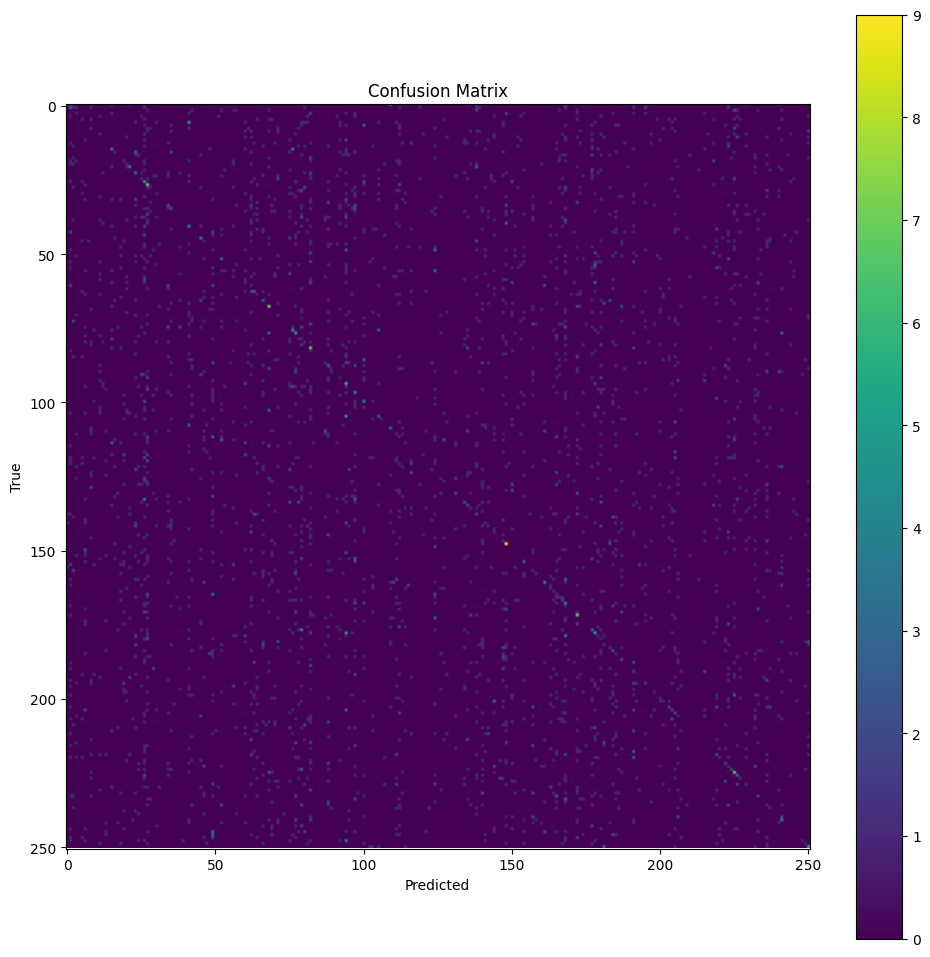

In [76]:
cm = confusion_matrix(t_all_labels, t_all_preds)
plt.figure(figsize=(12, 12))
plt.imshow(cm)
plt.colorbar()
plt.xlabel("Predicted")
plt.ylabel("True")
plt.title("Confusion Matrix")
plt.show()